# Install Libraries

In [1]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install cpi

Note: you may need to restart the kernel to use updated packages.


In [13]:
pip install cpi

Note: you may need to restart the kernel to use updated packages.


In [18]:
import sys
print(sys.executable)

C:\Users\pepec\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe


In [17]:
import cpi


OperationalError: no such table: series

In [ ]:
%pip install plotly

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ------ --------------------------------- 1.6/9.9 MB 10.5 MB/s eta 0:00:01
   --------------------- ------------------ 5.2/9.9 MB 13.9 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.9 MB 17.3 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 16.7 MB/s  0:00:00

   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   -------------------- ------------------- 1/2 [plotly]
   -------------------- -------------

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import plotly.graph_objects as go
import numpy as np

# Reading the CSV File 

In [ ]:
url = "https://raw.githubusercontent.com/AlvaDave/MTA-Inflation-Project/refs/heads/main/MTA%20Raw%20Data.csv"
df = pd.read_csv(url)
df.head()

,Year,Fare,30 Day Unlimited,14 Day Unlimited,7 Day Unlimited,1 Day
0,1904,$0.05,NaN,NaN,NaN,NaN
1,1905,$0.05,NaN,NaN,NaN,NaN
2,1906,$0.05,NaN,NaN,NaN,NaN
3,1907,$0.05,NaN,NaN,NaN,NaN
4,1908,$0.05,NaN,NaN,NaN,NaN


# Cleaning Data

In [ ]:
# Renaming columns
df.columns = [
    "year",
    "base_fare",
    "30unlimited",
    "14unlimited",
    "7unlimited",
    "1unlimited"]
df.head()

,year,base_fare,30unlimited,14unlimited,7unlimited,1unlimited
0,1904,$0.05,NaN,NaN,NaN,NaN
1,1905,$0.05,NaN,NaN,NaN,NaN
2,1906,$0.05,NaN,NaN,NaN,NaN
3,1907,$0.05,NaN,NaN,NaN,NaN
4,1908,$0.05,NaN,NaN,NaN,NaN


In [ ]:
# Remove Dollar Sign and Commas
df = df.replace(r"\$", "", regex=True)
df = df.replace(r",", "", regex=True)
df.head()

,year,base_fare,30unlimited,14unlimited,7unlimited,1unlimited
0,1904,0.05,NaN,NaN,NaN,NaN
1,1905,0.05,NaN,NaN,NaN,NaN
2,1906,0.05,NaN,NaN,NaN,NaN
3,1907,0.05,NaN,NaN,NaN,NaN
4,1908,0.05,NaN,NaN,NaN,NaN


In [ ]:
# Remove Dollar Signs and extra commasfor Specific Columns
dollar_col  = ["base_fare",
    "30unlimited",
    "14unlimited",
    "7unlimited",
    "1unlimited"]

for col in dollar_col: # creates loop for each column
    df[col] = (
        df[col] # overwrites the df[col] with df[col...]
            .astype(str) # converts to text to replace 
            .str.replace("$","")
            .str.replace(",","")
            .astype(float) # not int because integers can"t have decimals. 
    )
df.head()    

,year,base_fare,30unlimited,14unlimited,7unlimited,1unlimited
0,1904,0.05,NaN,NaN,NaN,NaN
1,1905,0.05,NaN,NaN,NaN,NaN
2,1906,0.05,NaN,NaN,NaN,NaN
3,1907,0.05,NaN,NaN,NaN,NaN
4,1908,0.05,NaN,NaN,NaN,NaN


In [ ]:
# Remove Extra Spaces 
df = df.apply(lambda col: col.str.strip() if col.dtype == "object" else col)

In [ ]:
# Year should remain as an integer and not string
df["year"] = (
    df["year"]
    .astype(str)      # make sure it"s text
    .str.strip()      # remove spaces at start/end
    .astype(int))      # convert to integer

In [ ]:
# Dataset starts at 1905. CPI was first recorded in 1913
df = df[df["year"] >= 1913]   # CPI starts in 1913

In [ ]:
# Year Index
df["year"] = pd.to_numeric(df["year"], errors="coerce") # Clean Year Column, numeric groups 
df = df.set_index("year")
df = df.sort_index() # sort over time
df.head()

,base_fare,30unlimited,14unlimited,7unlimited,1unlimited
year,,,,,
1913,0.05,NaN,NaN,NaN,NaN
1914,0.05,NaN,NaN,NaN,NaN
1915,0.05,NaN,NaN,NaN,NaN
1916,0.05,NaN,NaN,NaN,NaN
1917,0.05,NaN,NaN,NaN,NaN


# DONT DROP THIS NEXT TIME

In [ ]:
# Drop 2026 because there will be no CPI for the year 2026
df.drop(labels=[2026],inplace=True)

In [ ]:
 df.head(114)

,base_fare,30unlimited,14unlimited,7unlimited,1unlimited
year,,,,,
1913,0.05,NaN,NaN,NaN,NaN
1914,0.05,NaN,NaN,NaN,NaN
1915,0.05,NaN,NaN,NaN,NaN
1916,0.05,NaN,NaN,NaN,NaN
1917,0.05,NaN,NaN,NaN,NaN
...,...,...,...,...,...
2021,2.75,127.0,NaN,33.0,NaN
2022,2.75,127.0,NaN,33.0,NaN
2023,2.90,132.0,NaN,34.0,NaN


# Adjusting for Inflation WITHOUT FRED

In [ ]:
#df.reset_index(inplace=True)
#df.head(200)

In [ ]:
#df["cpi"] = df["year"].map(cpi.get)
#arget_cpi = cpi.get(2025)

#inflation_factor = target_cpi / df["cpi"]

#fare_cols = ["base_fare","30unlimited", "14unlimited","7unlimited","1unlimited"]

#df[[col + "_real_2023" for col in fare_cols]] = df[fare_cols].multiply(inflation_factor, axis=0)

In [ ]:
#df.head(200)

# Adjusting for Inflation WITH FRED

In [ ]:
pip install pandas-datareader

  Using cached pandas_datareader-0.10.0-py3-none-any.whl.metadata (2.9 kB)
Using cached pandas_datareader-0.10.0-py3-none-any.whl (109 kB)
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------- ----------------------------- 1.0/4.0 MB 8.4 MB/s eta 0:00:01
   --------------------------------- ------ 3.4/4.0 MB 10.1 MB/s eta 0:00:01
   ---------------------------------------- 4.0/4.0 MB 10.5 MB/s  0:00:00

   ---------------------------------------- 0/2 [lxml]
   ---------------------------------------- 0/2 [lxml]
   -------------------- ------------------- 1/2 [pandas-datareader]
   -------------------- ------------------- 1/2 [pandas-datareader]
   -------------------- ------------------- 1/2 [pandas-datareader]
   -------------------- ------------------- 1/2 [pandas-datareader]
   ---------------------------------------- 2/2 [pandas-datareader]

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas_datareader.data as web
import datetime

TypeError: deprecate_kwarg() missing 1 required positional argument: 'new_arg_name'

In [ ]:
# Desired time frame from FRED
start = datetime.datetime(1913,1,1)
end = datetime.datetime(2025,12,31)

cpi = web.DataReader("CPIAUCNS", "fred", start, end)
cpi.head()

,CPIAUCNS
DATE,
1913-01-01,9.8
1913-02-01,9.8
1913-03-01,9.8
1913-04-01,9.8
1913-05-01,9.7


In [ ]:
# Find the mean in years
cpi_yearly = cpi.resample("YE").mean()
# Change it to index to simplify the year values
cpi_yearly.index = cpi_yearly.index.year

cpi_yearly.head()

,CPIAUCNS
DATE,
1913,9.883333
1914,10.016667
1915,10.108333
1916,10.883333
1917,12.825000


In [ ]:
# Reset the index
cpi_yearly = cpi_yearly.reset_index()
# Rename columns
cpi_yearly.columns = ["year","cpi"]
cpi_yearly.head()

,year,cpi
0,1913,9.883333
1,1914,10.016667
2,1915,10.108333
3,1916,10.883333
4,1917,12.825000


In [ ]:
# Merge cpi_yearly and df
df = df.merge(cpi_yearly, on="year", how="left")

In [ ]:
df.head()

,year,base_fare,30unlimited,14unlimited,7unlimited,1unlimited,cpi
0,1913,0.05,NaN,NaN,NaN,NaN,9.883333
1,1914,0.05,NaN,NaN,NaN,NaN,10.016667
2,1915,0.05,NaN,NaN,NaN,NaN,10.108333
3,1916,0.05,NaN,NaN,NaN,NaN,10.883333
4,1917,0.05,NaN,NaN,NaN,NaN,12.825000


In [ ]:
# 2025 will be the base year as it is the most recent year
target_cpi = cpi_yearly.loc[cpi_yearly["year"] == 2025, "cpi"].values[0]

fare_cols = ["base_fare","30unlimited","14unlimited","7unlimited","1unlimited"]

inflation_factor = target_cpi / df["cpi"]

df[[col+"_real_2025" for col in fare_cols]] = \
    df[fare_cols].multiply(inflation_factor, axis=0)

In [ ]:
pip install aquarel

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from aquarel import load_theme

theme = load_theme("arctic_light")
theme.apply()

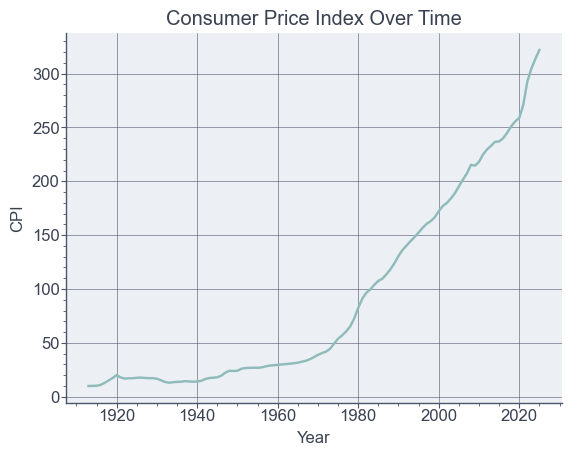

In [ ]:
with load_theme("arctic_light"):
    plt.figure()

plt.plot(cpi_yearly["year"], cpi_yearly["cpi"])

plt.title("Consumer Price Index Over Time")

plt.xlabel("Year")
plt.ylabel("CPI")

plt.show()

In [ ]:
df.head(200)

,year,base_fare,30unlimited,14unlimited,7unlimited,1unlimited,cpi,base_fare_real_2025,30unlimited_real_2025,14unlimited_real_2025,7unlimited_real_2025,1unlimited_real_2025
0,1913,0.05,NaN,NaN,NaN,NaN,9.883333,1.628717,NaN,NaN,NaN,NaN
1,1914,0.05,NaN,NaN,NaN,NaN,10.016667,1.607037,NaN,NaN,NaN,NaN
2,1915,0.05,NaN,NaN,NaN,NaN,10.108333,1.592463,NaN,NaN,NaN,NaN
3,1916,0.05,NaN,NaN,NaN,NaN,10.883333,1.479064,NaN,NaN,NaN,NaN
4,1917,0.05,NaN,NaN,NaN,NaN,12.825000,1.255138,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
108,2021,2.75,127.0,NaN,33.0,NaN,270.969750,3.267314,150.890500,NaN,39.207768,NaN
109,2022,2.75,127.0,NaN,33.0,NaN,292.654917,3.025212,139.709804,NaN,36.302547,NaN
110,2023,2.90,132.0,NaN,34.0,NaN,304.701583,3.064095,139.469167,NaN,35.923876,NaN
111,2024,2.90,132.0,NaN,34.0,NaN,313.688833,2.976308,135.473346,NaN,34.894650,NaN


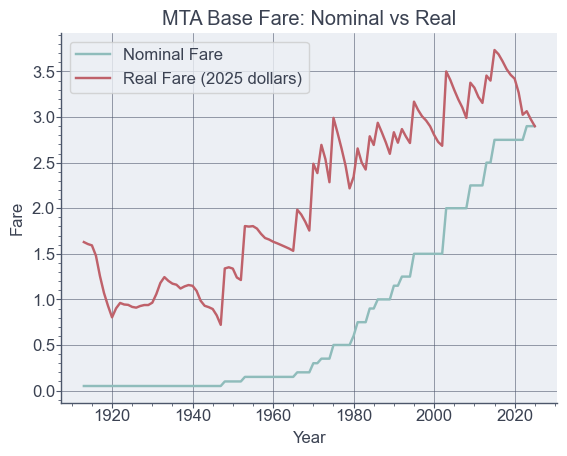

In [ ]:
plt.figure()

plt.plot(df["year"], df["base_fare"], label="Nominal Fare")

plt.plot(df["year"], df["base_fare_real_2025"], label="Real Fare (2025 dollars)")

plt.title("MTA Base Fare: Nominal vs Real")

plt.xlabel("Year")

plt.ylabel("Fare")

plt.legend()

plt.show()

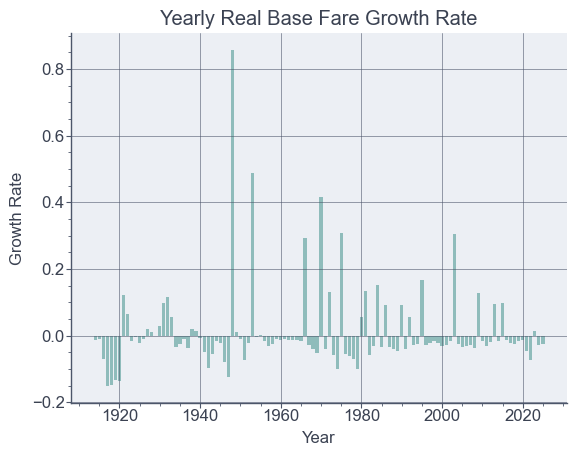

In [ ]:
df["fare_growth"] = df["base_fare_real_2025"].pct_change()

plt.figure()

plt.bar(df["year"], df["fare_growth"])

plt.title("Yearly Real Base Fare Growth Rate")

plt.xlabel("Year")

plt.ylabel("Growth Rate")

plt.show()

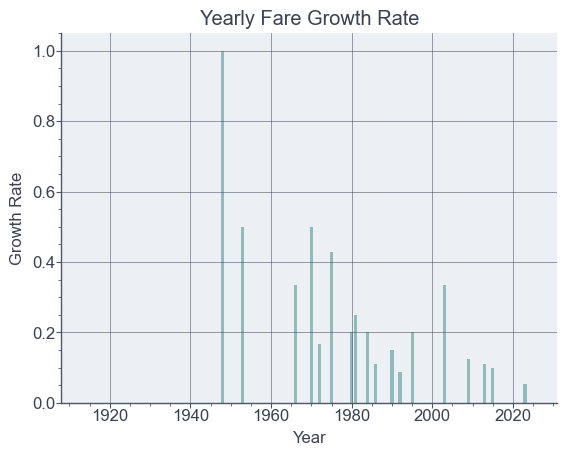

In [ ]:
df["fare_growth"] = df["base_fare"].pct_change()

plt.figure()

plt.bar(df["year"], df["fare_growth"])

plt.title("Yearly Fare Growth Rate")

plt.xlabel("Year")

plt.ylabel("Growth Rate")

plt.show()

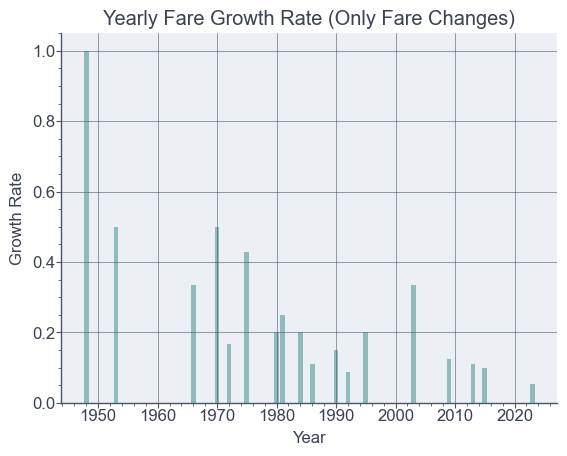

In [ ]:
df["fare_growth"] = df["base_fare"].pct_change()

growth_years = df[df["fare_growth"] != 0]

plt.figure()

plt.bar(growth_years["year"], growth_years["fare_growth"])

plt.title("Yearly Fare Growth Rate (Only Fare Changes)")

plt.xlabel("Year")

plt.ylabel("Growth Rate")

plt.show()

In [ ]:
import numpy as np

In [ ]:
growth_years.head(50)

,year,base_fare,30unlimited,14unlimited,7unlimited,1unlimited,cpi,base_fare_real_2025,30unlimited_real_2025,14unlimited_real_2025,7unlimited_real_2025,1unlimited_real_2025,fare_growth
0,1913,0.05,NaN,NaN,NaN,NaN,9.883333,1.628717,NaN,NaN,NaN,NaN,NaN
35,1948,0.10,NaN,NaN,NaN,NaN,24.041667,1.339104,NaN,NaN,NaN,NaN,1.000000
40,1953,0.15,NaN,NaN,NaN,NaN,26.766667,1.804164,NaN,NaN,NaN,NaN,0.500000
53,1966,0.20,NaN,NaN,NaN,NaN,32.458333,1.983731,NaN,NaN,NaN,NaN,0.333333
57,1970,0.30,NaN,NaN,NaN,NaN,38.825000,2.487647,NaN,NaN,NaN,NaN,0.500000
59,1972,0.35,NaN,NaN,NaN,NaN,41.816667,2.694621,NaN,NaN,NaN,NaN,0.166667
62,1975,0.50,NaN,NaN,NaN,NaN,53.816667,2.991109,NaN,NaN,NaN,NaN,0.428571
67,1980,0.60,NaN,NaN,NaN,NaN,82.408333,2.344008,NaN,NaN,NaN,NaN,0.200000
68,1981,0.75,NaN,NaN,NaN,NaN,90.925000,2.655565,NaN,NaN,NaN,NaN,0.250000
71,1984,0.90,NaN,NaN,NaN,NaN,103.883333,2.789174,NaN,NaN,NaN,NaN,0.200000


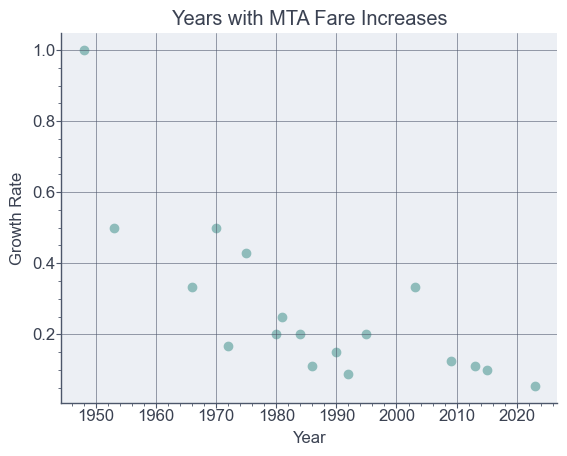

In [ ]:
plt.figure()

plt.scatter(growth_years["year"], growth_years["fare_growth"])

plt.title("Years with MTA Fare Increases")

plt.xlabel("Year")

plt.ylabel("Growth Rate")

plt.show()

In [ ]:
import numpy as np

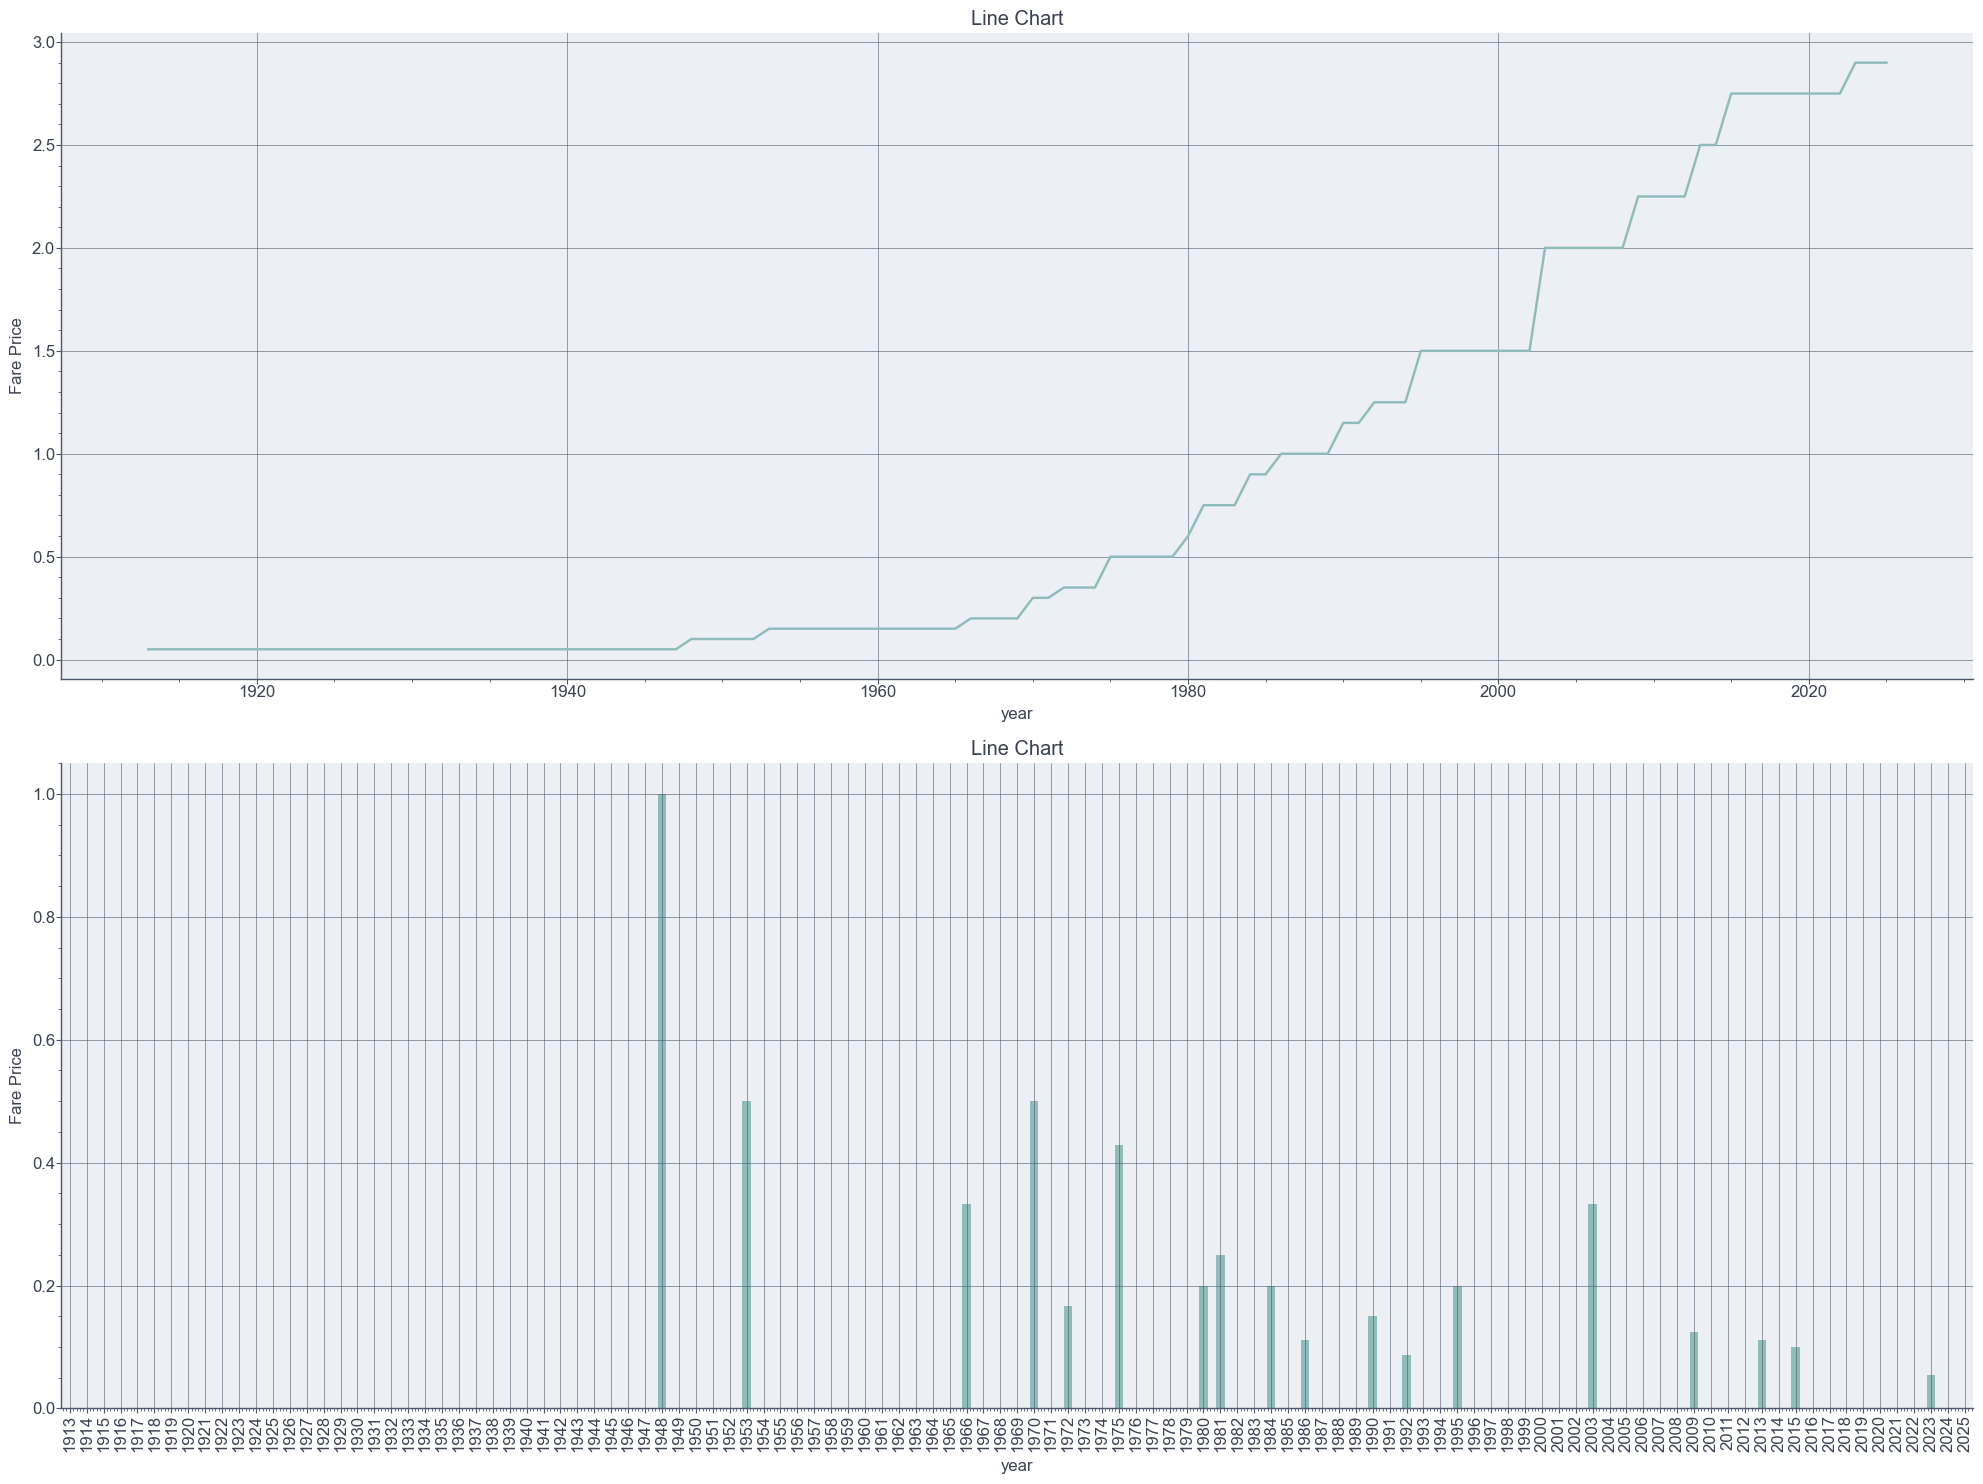

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(20, 15) )
df.plot(kind='line', y='base_fare', x='year', ax=axes[0], title='Line Chart', legend=False)
axes[0].set_ylabel('Fare Price')

df.plot(kind='bar', y='fare_growth', x='year', ax=axes[1], title='Line Chart', legend=False)
axes[1].set_ylabel('Fare Price')

plt.tight_layout()

# 6. Display the plots
plt.show()

<Figure size 640x480 with 0 Axes>

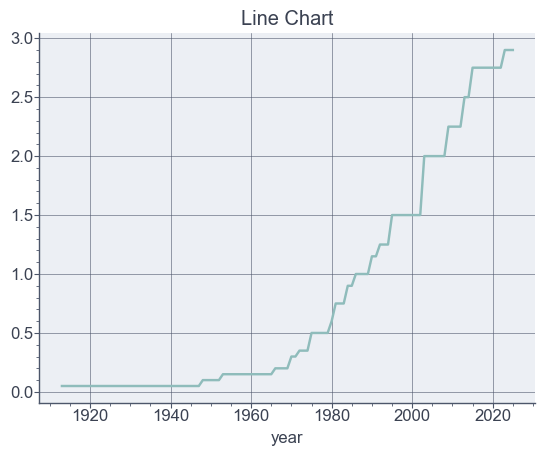

In [ ]:
plt.figure()
df.plot(kind='line', y='base_fare', x='year', title='Line Chart', legend=False)
plt.show()

KeyError: '30unlimited_real_2025'

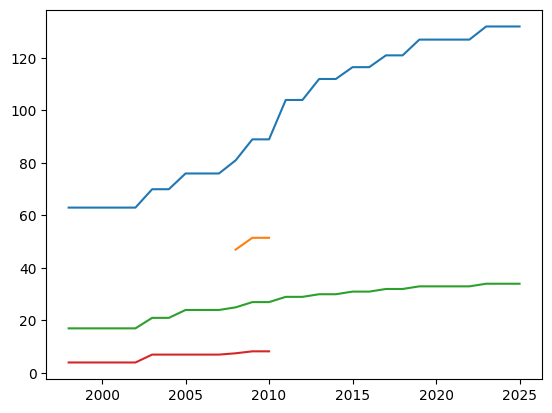

In [ ]:
plt.figure()

for col in ["30unlimited","14unlimited","7unlimited","1unlimited", 
            "30unlimited_real_2025", "14unlimited_real_2025", "7unlimited_real_2025", "1unlimited_real_2025"]:
    plt.plot(df["year"], df[col], label=col)

plt.title("MTA Fare Types Over Time")

plt.xlabel("Year")

plt.ylabel("Fare")

plt.legend()

plt.show()

In [ ]:
import sys
!{sys.executable} -m pip install dash

In [ ]:
# Import packages
from dash import Dash, html, dcc

In [ ]:
from dash import dcc, html, Input, Output
import plotly.express as px

In [ ]:
df.columns

Index(['base_fare', '30unlimited', '14unlimited', '7unlimited', '1unlimited'], dtype='str')

In [ ]:
pip install dash-ag-grid

  Using cached flask-3.1.3-py3-none-any.whl.metadata (3.2 kB)
  Using cached retrying-1.4.2-py3-none-any.whl.metadata (5.5 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached itsdangerous-2.2.0-py3-none-any.whl.metadata (1.9 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
   ---------------------------------------- 0.0/5.8 MB ? eta -:--:--
   ------- -------------------------------- 1.0/5.8 MB 5.6 MB/s eta 0:00:01
   ----------------- ---------------------- 2.6/5.8 MB 6.9 MB/s eta 0:00:01
   ----------------------------------- ---- 5.2/5.8 MB 8.9 MB/s eta 0:00:01
   ---------------------------------------- 5.8/5.8 MB 9.2 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   --------------------- ------------------ 3.9/7.2 MB 19.6 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 21.3 MB/s  0:00:00
Using cached flask-3.1.3-py3-none-any.whl (103 kB)
Using cached blinker-1.9.0-py3-none-

In [ ]:
import dash_ag_grid as dag


In [ ]:
# Initialize the app
app = dash.Dash()

# App layout
app.layout = [
    html.Div(children='My First App with Data and a Graph'),
    dag.AgGrid(
        rowData=df.to_dict('records'),
        columnDefs=[{"field": i} for i in df.columns]
    ),
    dcc.Graph(figure=px.histogram(df, x='year', y='fare_growth', histfunc='avg'))
]

# Run the app
if __name__ == '__main__':
    app.run(debug=True)

NameError: name 'dash' is not defined

In [ ]:
df.columns

Index(['year', 'base_fare', '30unlimited', '14unlimited', '7unlimited',
       '1unlimited', 'cpi', 'base_fare_real_2025', '30unlimited_real_2025',
       '14unlimited_real_2025', '7unlimited_real_2025', '1unlimited_real_2025',
       'fare_growth'],
      dtype='object')

In [ ]:
# List of columns to check for changes
fare_columns = ["base_fare", "30unlimited", "14unlimited", "7unlimited", "1unlimited"]

# Dictionary to store the results
change_history = {}

for col in fare_columns:
    # 1. Remove rows where the column is empty (NaN)
    valid_data = df.dropna(subset=[col]).copy()
    
    if not valid_data.empty:
        # 2. Identify rows where the price is different from the previous row
        # shift() moves data down one row for comparison
        price_changed = valid_data[col] != valid_data[col].shift()
        
        # 3. Extract the 'year' values for those specific rows
        change_years = valid_data.loc[price_changed, "year"].tolist()
        
        # 4. Save to dictionary
        change_history[col] = change_years

# Print the final dictionary
for fare, years in change_history.items():
    print(f"{fare}: {years}")

base_fare: [1913, 1948, 1953, 1966, 1970, 1972, 1975, 1980, 1981, 1984, 1986, 1990, 1992, 1995, 2003, 2009, 2013, 2015, 2023]
30unlimited: [1998, 2003, 2005, 2008, 2009, 2011, 2013, 2015, 2017, 2019, 2023]
14unlimited: [2008, 2009]
7unlimited: [1998, 2003, 2005, 2008, 2009, 2011, 2013, 2015, 2017, 2019, 2023]
1unlimited: [1998, 2003, 2008, 2009]


In [ ]:
# List of columns to check for changes
fare_columns = ["base_fare", "30unlimited", "14unlimited", "7unlimited", "1unlimited"]

# Dictionary to store the results
change_history1 = {}

for col in fare_columns:
    # 1. Remove rows where the column is empty (NaN)
    valid_data1 = df.dropna(subset=[col])
    
        # 2. Identify rows where the price is different from the previous row
        # shift() moves data down one row for comparison
    price_changed1 = valid_data1[col] != valid_data1[col].shift()
        
        # 3. Extract the 'year' values for those specific rows
    change_years1 = valid_data1.loc[price_changed1, "year"].tolist()
        
        # 4. Save to dictionary
    change_history1[col] = change_years1

# Print the final dictionary
for fare, years in change_history1.items():
    print(f"{fare}: {years}")

base_fare: [1913, 1948, 1953, 1966, 1970, 1972, 1975, 1980, 1981, 1984, 1986, 1990, 1992, 1995, 2003, 2009, 2013, 2015, 2023]
30unlimited: [1998, 2003, 2005, 2008, 2009, 2011, 2013, 2015, 2017, 2019, 2023]
14unlimited: [2008, 2009]
7unlimited: [1998, 2003, 2005, 2008, 2009, 2011, 2013, 2015, 2017, 2019, 2023]
1unlimited: [1998, 2003, 2008, 2009]


In [ ]:
# Create Dash app
app = Dash(__name__)


# Dictionary mapping dropdown labels to dataframe column names
fare_options = {
    "Base Fare": "base_fare",
    "30 Day Unlimited": "30unlimited",
    "14 Day Unlimited": "14unlimited",
    "7 Day Unlimited": "7unlimited",
    "1 Day Unlimited": "1unlimited"
}


# Layout controls what appears on the dashboard
app.layout = html.Div([

    # Title of dashboard
    html.H1("NYC MTA Fare History Dashboard"),

    # Dropdown menu to select fare type
    dcc.Dropdown(
        id="fare_dropdown",

        # Create dropdown options from the dictionary above
        options=[{"label": k, "value": v} for k, v in fare_options.items()],

        # Default selection
        value="base_fare",

        # Width of dropdown
        style={"width": "300px"}
    ),

    # Checkbox that toggles inflation adjustment
    dcc.Checklist(

        id="adjust_checkbox",

        options=[
            {"label": "Adjusted for 2025", "value": "adjusted"}
        ],

        # Empty list means unchecked by default
        value=[]
    ),

    # Graph where the fare data will appear
    dcc.Graph(id="fare_graph")

])


# Callback updates the graph when dropdown or checkbox changes
@app.callback(

    # The output we want to update
    Output("fare_graph", "figure"),

    # Inputs that trigger the update
    Input("fare_dropdown", "value"),
    Input("adjust_checkbox", "value")
)

def update_graph(selected_fare, checkbox_value):

    # Create a new figure
    fig = px.line()

    # Add the nominal fare line
    fig.add_scatter(
        x=df["year"],
        y=df[selected_fare],
        mode="lines",
        name="Nominal Fare"
    )

    # If checkbox is selected, also plot the inflation-adjusted fare
    if "adjusted" in checkbox_value:

        # Create column name for real 2025 dollars
        adjusted_column = selected_fare + "_real_2025"

        fig.add_scatter(
            x=df["year"],
            y=df[adjusted_column],
            mode="lines",
            name="Adjusted to 2025 Dollars"
        )

    # Update chart titles and axis labels
    fig.update_layout(
        title="NYC Transit Fare Over Time",
        xaxis_title="Year",
        yaxis_title="Fare ($)"
    )

    # Return the updated figure
    return fig


# Run the Dash server
app.run(debug=True)

In [ ]:
pip install fredapi pandas

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from fredapi import Fred
import pandas as pd

# Initialize with your API key
fred = Fred(api_key='d7071fb571792adbdbb59767ef31e9e7 ')

# Series ID for Median Household Income in New York County/City
# MHINY36000A052NCEN (Median Household Income for NYC)
# MEHOINUSNYA646N (Median Household Income in New York State - alternative)
series_id = 'MHINY36000A052NCEN'

# Get the series data
nyc_income = fred.get_series(series_id)

# Convert to pandas DataFrame for better handling
dfred = pd.DataFrame(nyc_income, columns=['Median_Income'])
dfred.head(50)

,Median_Income
1989-01-01,31229.0
1990-01-01,NaN
1991-01-01,NaN
1992-01-01,NaN
1993-01-01,32654.0
1994-01-01,NaN
1995-01-01,33805.0
1996-01-01,35696.0
1997-01-01,36369.0
1998-01-01,38290.0


In [ ]:
# Base fare costs a year vs median income 
# Weekly costs a year vs median income
# Monthly costs a year vs median income

In [ ]:
# OMNY caps spending at $35 a week
x = 35 * 52
y = x/85768
print(y)

0.021220035444454808


In [ ]:
print(x)

1820


In [ ]:
import plotly.express as px
import plotly.graph_objects as go

In [ ]:
# 1. Define the fare types and their display labels
fare_mapping = {
    "base_fare": "Base Fare",
    "30unlimited": "30 Day Unlimited",
    "14unlimited": "14 Day Unlimited",
    "7unlimited": "7 Day Unlimited",
    "1unlimited": "1 Day Unlimited"
}

# This 'config' dictionary disables the zoom, pan, and the floating menu
chart_config = {
    'scrollZoom': False,      # Disables mouse-wheel zoom
    'displayModeBar': False,  # Hides the floating toolbar entirely
    'showAxisDragHandles': False,
    'showAxisRangeEntryBoxes': False
}

In [ ]:
df = df.reset_index()

In [ ]:
print(df.columns)

Index(['year', 'base_fare', '30unlimited', '14unlimited', '7unlimited',
       '1unlimited'],
      dtype='str')


In [ ]:
# I dont think I need this line of code

def create_locked_charts():
    for col, label in fare_mapping.items():
        
        # --- Create Nominal Chart ---
        fig_nom = px.line(df, x="year", y=col, title=f"MTA {label} History")
        
        # LOCKING THE AXES: fixedrange=True prevents zooming and panning
        fig_nom.update_xaxes(range=[1913, 2025], fixedrange=True)
        fig_nom.update_yaxes(fixedrange=True)
        
        # Save with the config
        fig_nom.write_html(f"{col}.html", include_plotlyjs='cdn', config=chart_config)

        # --- Create Adjusted Chart ---
        adj_col = f"{col}_real_2025"
        fig_adj = go.Figure()
        fig_adj.add_trace(go.Scatter(x=df["year"], y=df[col], name="Nominal"))
        fig_adj.add_trace(go.Scatter(x=df["year"], y=df[adj_col], name="Adjusted"))

        fig_adj.update_layout(
            title=f"MTA {label}: Price vs. Inflation",
            xaxis=dict(range=[1913, 2025], fixedrange=True), # Lock X
            yaxis=dict(fixedrange=True),                     # Lock Y
            hovermode="x unified"
        )

        # Save with the config
        fig_adj.write_html(f"{col}_adjusted.html", include_plotlyjs='cdn', config=chart_config)

    print("Locked charts generated! The user can no longer zoom or pan.")

if __name__ == "__main__":
    create_locked_charts()

KeyError: 'base_fare_real_2025'

In [ ]:
fare_mapping = {
    "base_fare": "Base-Fare",
    "30unlimited": "30-Day Unlimited",
    "14unlimited": "14-Day Unlimited",
    "7unlimited": "7-Day Unlimited",
    "1unlimited": "1-Day Unlimited"
}

chart_config = {'displayModeBar': False}

In [ ]:
# 1. Ensure the Global Color Map is defined
fare_styles = {
        "base_fare": {"name": "Base Fare", "adj": "base_fare_real_2025", "color": "#0039A6"},   # Blue 
        "30unlimited": {"name": "30-Day Unlimited", "adj": "30unlimited_real_2025", "color": "#EE352E"},  # Red 
        "7unlimited": {"name": "7-Day Unlimited", "adj": "7unlimited_real_2025", "color": "#B933AD"},    # Purple 
        "14unlimited": {"name": "14-Day Unlimited", "adj": "14unlimited_real_2025", "color": "#00933C"}, # Green 
        "1unlimited": {"name": "1-Day Unlimited", "adj": "1unlimited_real_2025", "color": "#FF6319"}     # Orange 
    }

def create_dynamic_charts():
    for col, info in fare_styles.items():
        # DATA FILTERING
        valid_data = df[df[col].notna()].copy()
        if valid_data.empty: continue

        label = info['name']
        line_color = info['color']
        adj_col = info['adj']
        
        start_year = int(valid_data["year"].min())
        end_year = int(valid_data["year"].max())
        year_gap = end_year - start_year
        
        # Smart Tick Logic
        if year_gap > 50: my_dtick = 20
        elif year_gap > 15: my_dtick = 5
        else: my_dtick = 2

        # --- NOMINAL CHART ---
        fig_nom = px.line(valid_data, x="year", y=col, title=f"MTA {label} (Nominal)")
        fig_nom.update_traces(line_color=line_color, line_width=2.5, 
                              hovertemplate="<b>%{fullData.name}</b>: $%{y:.2f}<extra></extra>")
        
        fig_nom.update_layout(
            hovermode="x unified",
            showlegend=False, # Hides the bottom legend
            margin=dict(t=80, b=50),
            plot_bgcolor='white'
        )

        # --- ADJUSTED CHART (Matching Colors) ---
        if adj_col in df.columns:
            fig_adj = go.Figure()
            
            # Adjusted Line (Solid, Bold)
            fig_adj.add_trace(go.Scatter(
                x=valid_data["year"], y=valid_data[adj_col], 
                name=f"{label} (Adjusted)",
                line=dict(color=line_color, width=2, dash='dot'),
                hovertemplate="<b>%{fullData.name}</b>: $%{y:.2f}<extra></extra>"
            ))
            
            # Nominal Line (Dotted, Thinner)
            fig_adj.add_trace(go.Scatter(
                x=valid_data["year"], y=valid_data[col], 
                name=f"{label} (Nominal)",
                line=dict(color=line_color, width=2.5),
                hovertemplate="<b>%{fullData.name}</b>: $%{y:.2f}<extra></extra>"
            ))

            fig_adj.update_layout(
                title=f"MTA {label}: Price vs. Inflation",
                hovermode="x unified",
                showlegend=False, # Hides the bottom legend
                margin=dict(t=80, b=50),
                plot_bgcolor='white'
            )

        # Common Formatting for both Nominal and Adjusted
        for fig in [fig_nom, fig_adj]:
            fig.update_xaxes(range=[start_year, end_year], tickformat="d", 
                             dtick=my_dtick, gridcolor='#eeeeee', fixedrange=True)
            fig.update_yaxes(tickprefix="$", tickformat=".2f", 
                             gridcolor='#eeeeee', fixedrange=True)
        
        # Save the files
        safe_filename = col.replace(" ", "_")
        fig_nom.write_html(f"{safe_filename}.html", include_plotlyjs='cdn', config=chart_config)
        fig_adj.write_html(f"{safe_filename}_adjusted.html", include_plotlyjs='cdn', config=chart_config)

    print("Dynamic charts updated: Consistent colors applied and legends hidden.")

# Run the updated function
create_dynamic_charts()

UnboundLocalError: cannot access local variable 'fig_adj' where it is not associated with a value

In [ ]:
# 1. Global Color Mapping (Ensures consistency across all 12+ files)
fare_styles = {
    "base_fare": {"name": "Base Fare", "adj": "base_fare_real_2025", "color": "#0039A6"},   # Blue 
    "30unlimited": {"name": "30-Day Unlimited", "adj": "30unlimited_real_2025", "color": "#EE352E"},  # Red 
    "7unlimited": {"name": "7-Day Unlimited", "adj": "7unlimited_real_2025", "color": "#B933AD"},    # Purple 
    "14unlimited": {"name": "14-Day Unlimited", "adj": "14unlimited_real_2025", "color": "#00933C"}, # Green 
    "1unlimited": {"name": "1-Day Unlimited", "adj": "1unlimited_real_2025", "color": "#FF6319"}     # Orange 
}

def create_master_comparisons():
    # --- SORTING LOGIC ---
    # Sort keys by the latest price (Adjusted) to organize the legend
    sorted_keys = sorted(
        [k for k in fare_styles.keys() if k in df.columns],
        key=lambda k: df[fare_styles[k]['adj']].dropna().iloc[-1] if not df[fare_styles[k]['adj']].dropna().empty else 0,
        reverse=True
    )
    
      # --- CHART 1: NOMINAL COMPARISON ---
    fig_nom = go.Figure()
    for key in sorted_keys:
        info = fare_styles[key]
        fig_nom.add_trace(go.Scatter(
            x=df["year"], 
            y=df[key], 
            name=f"{info['name']}",
            line=dict(color=info['color'], width=2.5),
            hovertemplate="<b>%{fullData.name}</b>: $%{y:.2f}<extra></extra>"
        ))

    # --- CHART 2: ADJUSTED COMPARISON (Real Value vs. Sticker Price) ---
    fig_adj = go.Figure()
    # Adjusted Lines (Dotted, Thin Same Color)
    for key in sorted_keys:
        info = fare_styles[key]
        if info['adj'] in df.columns:
            fig_adj.add_trace(go.Scatter(
                x=df["year"], 
                y=df[info['adj']], 
                name=f"{info['name']}",
                showlegend=False, # Hide from legend to keep it clean
                line=dict(color=info['color'], width=2, dash='dot'),
                hovertemplate="<b>%{fullData.name} (Adjusted)</b>: $%{y:.2f}<extra></extra>"
            ))
    # Nominal Line (Bold Solid)
            fig_adj.add_trace(go.Scatter(
                x=df["year"], 
                y=df[key], 
                name=f"{info['name']}",
                showlegend=True, # Show in legend as the color key
                line=dict(color=info['color'], width=2.5), 
                hovertemplate="<b>%{fullData.name} (Nominal)</b>: $%{y:.2f}<extra></extra>"
            ))

    # --- SHARED LAYOUT SETTINGS ---
    layout_settings = dict(
        title_x=0.5,
        hovermode="x unified",
        showlegend=True,
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.015, # Slightly higher for better spacing
            xanchor="center",
            x=0.5,
            traceorder="normal" # Follows our sorted loop order
        ),
        margin=dict(t=120, b=50, l=60, r=40),
        xaxis=dict(showgrid=True, gridcolor='lightgrey',range=[1998,2025]), # Optional: colors the 0-line
        yaxis=dict(showgrid=True, gridcolor='lightgrey',range=[0,160]),
        plot_bgcolor='white',
        dragmode=False,
    )
   
    # CHART TITLES
    fig_nom.update_layout(title="Recent MTA Fares Comparison (1998-2025)", **layout_settings)
    fig_adj.update_layout(title="Recent MTA Fares: Base Price vs. Inflation-Adjusted Value (1998-2025)", **layout_settings)

    # Apply Standard Formatting to both
    for fig in [fig_nom, fig_adj]:
        fig.update_xaxes(
            title="Year",
            range=[1998, 2025], 
            dtick=2, 
            tickformat="d", 
            fixedrange=True
        )
    
        fig.update_yaxes(
            title="Fare Prices", 
            tickprefix="$", 
            tickformat=".2f", 
            fixedrange=True, 
            zerolinecolor="lightgrey",
            linecolor="lightgrey",
            showline=True    
        )
        
    for fig in [fig_nom, fig_adj]:
        fig.add_hline(y=0, line_width=1, line_color="Black")
        fig.add_vline(x=1998, line_width=1, line_color="Black")

    # Save both files
    fig_nom.write_html("compare_all.html", include_plotlyjs='cdn', config=chart_config)
    fig_adj.write_html("compare_all_adjusted.html", include_plotlyjs='cdn', config=chart_config)
    
    print("Master Comparison Charts (Nominal & Adjusted) generated with unified colors and hidden legends.")

# Run the master generator
create_master_comparisons()

KeyError: 'base_fare_real_2025'

In [ ]:
if __name__ == "__main__":
    create_dynamic_charts()  # Generates the individual files
    create_master_comparisons() # Generates the combined file

KeyError: 'year'

# GROWTH RATE CHARTS

In [ ]:
def generate_mta_growth_series():
    # 1. Data Prep
    df_hikes = df.copy().sort_values('year')
    df_hikes['nom_growth'] = df_hikes['base_fare'].pct_change() * 100
    df_hikes['adj_growth'] = df_hikes['base_fare_real_2025'].pct_change() * 100
    df_hikes = df_hikes[df_hikes['nom_growth'] > 0].dropna(subset=['nom_growth', 'adj_growth'])

    # 2. Quadratic Calculations
    z_nom = np.polyfit(df_hikes['year'], df_hikes['nom_growth'], 3)
    p_nom = np.poly1d(z_nom)
    z_adj = np.polyfit(df_hikes['year'], df_hikes['adj_growth'], 3)
    p_adj = np.poly1d(z_adj)
    x_range = np.linspace(df_hikes['year'].min(), df_hikes['year'].max(), 100)

    # Formatting Equations
    eq_nom = f"Nominal: y = {z_nom[0]:.4f}x³ + ({z_nom[1]:.2f}x²) + ({z_nom[2]:.2f}x) + ({z_nom[3]:.2f})"
    eq_adj = f"Adjusted: y = {z_adj[0]:.4f}x³ + ({z_adj[1]:.2f}x²) + ({z_adj[2]:.2f}x) + ({z_adj[3]:.2f})"
    
    # 3. Common Layout & Config
    def apply_standard_layout(fig, title, include_equations=False):
        fig.update_layout(
            title=dict(text=title, x=0.5, font=dict(size=18)),
            xaxis=dict(
                title="Year of Hike", type='linear',
                tickvals=df_hikes['year'],
                range=[df_hikes['year'].min() - 1, df_hikes['year'].max() + 1],
                fixedrange=True, 
                gridcolor='#f0f0f0', 
                showgrid=False,
                zeroline=False
                
            ),
            yaxis=dict(
                title="Growth Rate (%)", range=[0, 100],
                fixedrange=True, 
                gridcolor='#f0f0f0',
                zeroline=False
            ),
            barmode='group',
            plot_bgcolor='white',
            showlegend=True,
            legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5),
            margin=dict(t=100, b=50, l=60, r=40),
            dragmode=False,
        )
        
        fig.add_hline(y=0, line_width=1, line_color="Black")
        fig.add_vline(x=1947, line_width=1, line_color="Black")            


        if include_equations:
            fig.add_annotation(
                text=f"<b>Trendline Equations</b><br>{eq_nom}<br>{eq_adj}",
                xref="paper", yref="paper",
                x=0.98, y=0.98,
                showarrow=False,
                align="right",
                bgcolor="rgba(255, 255, 255, 0.8)",
                bordercolor="lightgrey",
                borderwidth=1,
                font=dict(family="Courier New, monospace", size=10)
            )

    config = {'displayModeBar': False}
    
    # --- CHART 1: Nominal + Quadratic Trend ---
    fig1 = go.Figure()
    fig1.add_trace(go.Bar(x=df_hikes['year'], y=df_hikes['nom_growth'], name="Nominal Growth", marker_color='#0039A6'))
    fig1.add_trace(go.Scatter(hoverinfo='skip',x=x_range, y=p_nom(x_range), name="Nominal Trend", line=dict(color='#0039A6', width=3, dash='dash')))
    apply_standard_layout(fig1, "MTA Base Fare Growth Rate",)
    fig1.write_html("base_nominal_trend.html", config=config)

    # ADDED include_equations=True HERE
    apply_standard_layout(fig1, "MTA Base Fare Growth Rate", include_equations=False)
    fig1.write_html("base_nominal_trend.html", config=config)

    # --- CHART 2: Nominal & Adjusted + Both Trends ---
    fig2 = go.Figure()
    fig2.add_trace(go.Bar(x=df_hikes['year'], y=df_hikes['nom_growth'], name="Nominal", marker_color='#0039A6'))
    fig2.add_trace(go.Bar(x=df_hikes['year'], y=df_hikes['adj_growth'], name="Adjusted", marker_color='#4B8BBE'))
    fig2.add_trace(go.Scatter(hoverinfo='skip',x=x_range, y=p_nom(x_range), name="Nominal Trend", line=dict(color='#0039A6', width=3, dash='dash')))
    fig2.add_trace(go.Scatter(hoverinfo='skip',x=x_range, y=p_adj(x_range), name="Adjusted Trend", line=dict(color = '#4B8BBE', width=3, dash='dash')))
    apply_standard_layout(fig2, "Adjusted & Nominal MTA Base Fare Growth Rate")
    fig2.write_html("base_complete_analysis.html", config=config)

    # ADDED include_equations=True HERE
    apply_standard_layout(fig2, "Adjusted & Nominal MTA Base Fare Growth Rate", include_equations=False)
    fig2.write_html("base_complete_analysis.html", config=config)

    print("Two charts generated: Nominal Trend and Full Analysis.")

generate_mta_growth_series()

Two charts generated: Nominal Trend and Full Analysis.


In [ ]:
def generate_mta_fare_analysis_suite():
    # Define fare types with specific color schemes
    # Format: (Display Name, Nom Col, Adj Col, Primary Color, Light Color)
    
    fare_types = [
        ("Weekly Fare","7unlimited", "7unlimited_real_2025", "#800080", "#D8BFD8"), # Purple
        ("Monthly Fare","30unlimited", "30unlimited_real_2025", "#FF0000", "#FFCCCC") # Red
    ]

    for display_name, nom_col, adj_col, primary_color, light_color in fare_types:
        # 1. Data Prep
        df_hikes = df.copy().sort_values('year')
        df_hikes['nom_growth'] = df_hikes[nom_col].pct_change() * 100
        df_hikes['adj_growth'] = df_hikes[adj_col].pct_change() * 100
        
        # Filter for actual hike years
        df_hikes = df_hikes[df_hikes['nom_growth'] > 0].dropna(subset=['nom_growth', 'adj_growth'])

        if df_hikes.empty:
            continue

        # 2. Cubic Calculations (Degree 3)
        z_nom = np.polyfit(df_hikes['year'], df_hikes['nom_growth'], 3)
        p_nom = np.poly1d(z_nom)
        z_adj = np.polyfit(df_hikes['year'], df_hikes['adj_growth'], 3)
        p_adj = np.poly1d(z_adj)
        x_range = np.linspace(df_hikes['year'].min(), df_hikes['year'].max(), 100)
        
        prefix = display_name.lower().replace(" ", "_")

        # 3. Standard Layout Function
        def apply_standard_layout(fig, title):
            fig.update_layout(
                title=dict(text=title, x=0.5, font=dict(size=18)),
                xaxis=dict(
                    title="Year of Hike", 
                    type='linear',
                    tickvals=df_hikes['year'],
                    range=[df_hikes['year'].min()-1 , df_hikes['year'].max() + 1],
                    fixedrange=True, 
                    showgrid=False,
                    zeroline=False,
                    showline=True,
                ),
                yaxis=dict(
                    title="Growth Rate (%)", 
                    range=[0, 25],
                    fixedrange=True, 
                    gridcolor='#f0f0f0',
                    zeroline=False,
                    showline=True
                ),
                barmode='group',
                plot_bgcolor='white',
                showlegend=True,
                legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5),
                margin=dict(t=100, b=50, l=60, r=40),
                dragmode=False,
            )

            fig.add_hline(y=0, line_width=2, line_color="Black")
            fig.add_vline(x=2002, line_width=2, line_color="Black")            
            
            


        config = {'displayModeBar': False}

        # --- CHART 1: Nominal Only + Silent Trend ---
        fig1 = go.Figure()
        fig1.add_trace(go.Bar(
            x=df_hikes['year'], y=df_hikes['nom_growth'], 
            name=f"{display_name} Nominal", marker_color=primary_color,
        ))
        fig1.add_trace(go.Scatter(
            x=x_range, y=p_nom(x_range), 
            name="Nominal Trend", 
            line=dict(color=primary_color, width=3, dash='dash'),
            hoverinfo='skip',
        ))
        apply_standard_layout(fig1, f"MTA {display_name} Growth")
        fig1.write_html(f"{prefix}_nominal_trend.html", config=config)

        # --- CHART 2: Nominal & Adjusted + Silent Trends ---
        fig2 = go.Figure()
        fig2.add_trace(go.Bar(
            x=df_hikes['year'], y=df_hikes['nom_growth'], 
            name="Nominal", marker_color=primary_color,
        ))
        fig2.add_trace(go.Bar(
            x=df_hikes['year'], y=df_hikes['adj_growth'], 
            name="Inflation Adjusted", marker_color=light_color,
        ))
        fig2.add_trace(go.Scatter(
            x=x_range, y=p_nom(x_range), 
            name="Nominal Trend", 
            line=dict(color=primary_color, width=3, dash='dash'),
            hoverinfo='skip',
        ))
        fig2.add_trace(go.Scatter(
            x=x_range, y=p_adj(x_range), 
            name="Adjusted Trend", 
            line=dict(color=light_color, width=3, dash='dash'),
            hoverinfo='skip',
        ))
        apply_standard_layout(fig2, f"MTA {display_name} Comprehensive Analysis")
        fig2.write_html(f"{prefix}_complete_analysis.html", config=config)

    print("Success: Generated color-coded charts for Base (Blue), Weekly (Purple), and Monthly (Red).")

generate_mta_fare_analysis_suite()

Success: Generated color-coded charts for Base (Blue), Weekly (Purple), and Monthly (Red).


NameError: name 'df' is not defined

Charts generated. Interaction locked and axis borders added.


Dynamic charts updated: Consistent colors applied and legends hidden.
